In [5]:
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from astropy.table import Table
from astropy.io import fits
from astropy.visualization import simple_norm
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import re
from astropy.coordinates import SkyCoord
import sys
sys.path.append('/home/t.yoo/Paths')
import Paths.Paths as paths
import matplotlib as mpl
import matplotlib.patches as patches
Path = paths.filepaths()

import warnings
from astropy.wcs import FITSFixedWarning
from astroquery.svo_fps import SvoFps

warnings.filterwarnings("ignore", category=FITSFixedWarning)

plt.rcParams['axes.labelsize']=20
plt.rcParams['xtick.labelsize']=15
plt.rcParams['ytick.labelsize']=15
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f1500w": "/orange/adamginsburg/jwst/w51/F1500W/pipeline/jw06151-o002_t001_miri_f1500w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    "w51e_1.3mm": Path.w51e_b6_tt0,
    "w51e_3mm": Path.w51e_b3_tt0,
    "w51n_1.3mm": Path.w51n_b6_tt0,
    "w51n_3mm": Path.w51n_b3_tt0,
    "vla_22GHz": "/orange/adamginsburg/w51/TaehwaYoo/vla/2016paper/W51-K-B.S1-ICLN.DAVID-MEH.fits",
    "vla_14GHz": "/orange/adamginsburg/w51/TaehwaYoo/vla/2016paper/W51Ku_C_Aarray_continuum_2048_high_uniform.clean.image.fits",
    "vla_8GHz": "/orange/adamginsburg/w51/TaehwaYoo/vla/2016paper/W51-X-ABCD-S1.VTESS.VTC.DAVID-MEH.fits",
    "vla_5GHz": "/orange/adamginsburg/w51/TaehwaYoo/vla/2016paper/W51-CBAND-feathered.fits"
}
catalogs_filters = {"f140m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f162m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f182m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f182m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f187n_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f187n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f210m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f210m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f335m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f335m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f360m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f360m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f405n_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f405n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f410m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f410m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f480m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f140m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f162m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                  "f182m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f182m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f187n_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f187n_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f210m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f210m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f335m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f335m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f360m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f360m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f405n_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f405n_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f410m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f410m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f480m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f560w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f560w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                   "f770w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f770w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                   "f1000w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1000w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                   "f1280w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1280w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                   "f2100w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f2100w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                   "vla": '/home/t.yoo/w51/w51_nircam/analysis/vla.fits',
                  }
                  
catalogs_filters_filtered = {"f140m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f162m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f182m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f182m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f187n_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f187n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f210m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f210m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f335m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f335m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f360m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f360m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f405n_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f405n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f410m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f410m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f480m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f140m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f162m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                  "f182m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f182m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f187n_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f187n_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f210m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f210m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f335m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f335m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f360m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f360m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f405n_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f405n_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f410m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f410m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f480m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f560w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f560w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_b_fixed.fits',
                   "f770w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f770w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_b_fixed.fits',
                   "f1000w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1000w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_b_fixed.fits',
                   "f1280w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1280w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_b_fixed.fits',
                   "f2100w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f2100w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_b_fixed.fits',
                   "vla": '/home/t.yoo/w51/w51_nircam/analysis/vla.fits',
                  }
reprojected_dir = '/orange/adamginsburg/jwst/w51/reproject_to_alma/'

def get_mag(flux, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    #flux= (flux * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
   # eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
 #   abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
#    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
 #   vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag


catalog = Table.read('/orange/adamginsburg/jwst/w51/catalogs/final_nircam_miri_indivexp_merged_dao_refined_after_sat.fits')
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')

def plot_SED(image_filenames, row_jwst, row_alma, row_vla, label, cutout_size=2*u.arcsec, alma_region='w51e', show=False):
    fig = plt.figure(figsize=(24, 20))
    gs = GridSpec(5,6, figure=fig, wspace=0, hspace=0)
    ax_f140m = fig.add_subplot(gs[0,0])
    ax_f162m = fig.add_subplot(gs[0,1])
    ax_f182m = fig.add_subplot(gs[0,2])
    ax_f187n = fig.add_subplot(gs[0,3])
    ax_f210m = fig.add_subplot(gs[0,4])
    ax_f335m = fig.add_subplot(gs[0,5])
    ax_f360m = fig.add_subplot(gs[1,0])
    ax_f405n = fig.add_subplot(gs[1,1])
    ax_f410m = fig.add_subplot(gs[1,2])
    ax_f480m = fig.add_subplot(gs[1,3])
    ax_f560w = fig.add_subplot(gs[1,4])
    ax_f770w = fig.add_subplot(gs[1,5])
    ax_f1000w = fig.add_subplot(gs[2,0])
    ax_f1280w = fig.add_subplot(gs[2,1])
    ax_f2100w = fig.add_subplot(gs[2,2])
    ax_b6 = fig.add_subplot(gs[2,3])
    ax_b3 = fig.add_subplot(gs[2,4])
    ax_vla_5GHz = fig.add_subplot(gs[2,5])
    ax_vla_8GHz = fig.add_subplot(gs[3,0])
    ax_vla_14GHz = fig.add_subplot(gs[3,1])
    ax_vla_22GHz = fig.add_subplot(gs[3,2])
    ax_images = [ax_f140m, ax_f162m, ax_f182m, ax_f187n, ax_f210m, ax_f335m, ax_f360m, ax_f405n,
                 ax_f410m, ax_f480m, ax_f560w, ax_f770w, ax_f1000w, ax_f1280w, ax_f2100w, ax_b6, ax_b3, ax_vla_5GHz, ax_vla_8GHz, ax_vla_14GHz, ax_vla_22GHz]
    ax_main = fig.add_subplot(gs[4, :])
    filter_names = ["f140m", "f162m", "f182m", "f187n", "f210m", "f335m", "f360m", "f405n",
                    "f410m", "f480m", "f560w", "f770w", "f1000w", "f1280w", "f2100w", "1.3mm", "3mm", "vla_5GHz", "vla_8GHz", "vla_14GHz", "vla_22GHz"]
    skycoords = SkyCoord(ra=catalog['skycoord_ref'].ra[idx], dec=catalog['skycoord_ref'].dec[idx])
    print('skycoords in h:m:s:', skycoords.to_string('hmsdms'))
    print(len(filter_names), len(ax_images))
    for i, ax in enumerate(ax_images):  
        img_b3 = image_filenames[f'{alma_region}_3mm']
        header_b3 = fits.open(img_b3)[0].header
        pixel_scale_b3 = WCS(header_b3, naxis=2).proj_plane_pixel_scales()[0]
        img_b6 = image_filenames[f'{alma_region}_1.3mm']
        header_b6 = fits.open(img_b6)[0].header
        pixel_scale_b6 = WCS(header_b6, naxis=2).proj_plane_pixel_scales()[0]

        if filter_names[i] in ["1.3mm", "3mm"]: 
            if filter_names[i] == "1.3mm":
                band = 'b6'
            elif filter_names[i] == "3mm":
                band = 'b3'
            img_filename = image_filenames[f"{alma_region}_{filter_names[i]}"]
            print('alma image filename:', img_filename)
            img = fits.open(img_filename)[0].data[0][0]
            header = fits.open(img_filename)[0].header
            wcs = WCS(header, naxis=2)
        elif filter_names[i] in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m', 'f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']:
            #filt}_reprojected_to_alma_w51n_b6.fits
            img_filename = reprojected_dir + f"{filter_names[i]}_reprojected_to_alma_{alma_region}_b3.fits"
            print('JWST image filename:', img_filename)
            img = fits.open(img_filename)[0].data
            header = fits.open(img_filename)[0].header
            wcs = WCS(header, naxis=2)
        else:
            
            image_filename = reprojected_dir + f"{filter_names[i]}_reprojected_to_alma_{alma_region}_b3.fits"
            img = fits.open(image_filename)[0].data
            if not len(img.shape) == 2:
                img = img[0][0]
            header = fits.open(image_filename)[0].header
            wcs = WCS(header, naxis=2)
          

        try:
        
            cutout = Cutout2D(img, skycoords, (cutout_size, cutout_size), wcs=wcs)
            norm = simple_norm(cutout.data, 'sqrt', percent=99.5)
            ax.imshow(cutout.data, norm=norm, origin='lower', cmap='inferno')
            if filter_names[i] == "1.3mm":
                pixel_scale = pixel_scale_b6
            else:
                pixel_scale = pixel_scale_b3
            print('pixel_scale:', pixel_scale)
                
            circle = patches.Circle((cutout.data.shape[1]/2, cutout.data.shape[0]/2), radius=(0.1*u.arcsec/pixel_scale).to(u.deg/u.deg).value, edgecolor='cyan', facecolor='none', lw=2)
            ax.add_patch(circle)
            print(filter_names[i])
            ax.text(0.1, 0.9, filter_names[i].upper(), transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
            ax.axis('off')
            ax.set_xlim(0, cutout.data.shape[1])
            ax.set_ylim(0, cutout.data.shape[0])
        except Exception as e:
            print(img.shape)
            pixcoord = skycoords.to_pixel(wcs)
            print('pixcoord:', pixcoord)
            print(f"Could not create cutout for filter {filter_names[i]}: {e}")
            continue      
        
            
        if not filter_names[i] in ['1.3mm', '3mm']:
            if filter_names[i] in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m']:
                cat_nrca = catalogs_filters_filtered[f'{filter_names[i]}_nrca']
                skycoord_nrca = Table.read(cat_nrca)['skycoord']
                print('catalog filename cat_nrca:', cat_nrca)
                pixcoord_nrca = skycoord_nrca.to_pixel(cutout.wcs)
                cat_nrcb = catalogs_filters_filtered[f'{filter_names[i]}_nrcb']
                print('catalog filename cat_nrcb:', cat_nrcb)

                skycoord_nrcb = Table.read(cat_nrcb)['skycoord']
                pixcoord_nrcb = skycoord_nrcb.to_pixel(cutout.wcs)
                ax.scatter(pixcoord_nrca[0], pixcoord_nrca[1], facecolor='none', color='blue', s=10)
                ax.scatter(pixcoord_nrcb[0], pixcoord_nrcb[1], facecolor='none', color='red', s=10)
                
            
            elif filter_names[i] in ['f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']:
                cat_miri = catalogs_filters_filtered[f'{filter_names[i]}']
                print('catalog filename cat_miri:', cat_miri)
                skycoord_miri = Table.read(cat_miri)['skycoord']
                pixcoord_miri = skycoord_miri.to_pixel(cutout.wcs)
                ax.scatter(pixcoord_miri[0], pixcoord_miri[1], facecolor='none', color='green', s=10)

            else:
                
                cat_vla = Table.read(catalogs_filters_filtered['vla'])
                print('catalog filename cat_vla:', catalogs_filters_filtered['vla'])
                ra = cat_vla['GRAdeg']
                dec = cat_vla['GDEdeg']
                skycoord_vla = SkyCoord(ra=ra, dec=dec)
                pixcoord_vla = skycoord_vla.to_pixel(cutout.wcs)
                ax.scatter(pixcoord_vla[0], pixcoord_vla[1], facecolor='none', color='magenta', s=10)

        # limit xlim ylim as same as cutout size
       
    # plot SED
    colors = mpl.cm.viridis(np.linspace(0, 1, len(filter_names)))
    fluxarr = []
    mag_f140m = None
    mag_f210m = None
    mag_f360m = None
    mag_f480m = None
    for i, filter_name in enumerate(filter_names):
        # Get the effective wavelength for each filter
      

        if filter_name == '1.3mm':
            wav = 130000
            flux = row_alma['flux_b6']
        elif filter_name == '3mm':
            wav = 300000
            flux = row_alma['flux_b3']
        elif filter_name in ["vla_5GHz", "vla_8GHz", "vla_14GHz", "vla_22GHz"]:
            if row_vla is not None:
                freq = row_vla['Freq']
                wav = (3e8 / (freq * 1e9)) * 1e6 # convert frequency in GHz to wavelength in micron
                flux = row_vla['FluxAp_jy']
        else:
            print(filter_name)
            wcs_filter = WCS(fits.getheader(image_filenames[filter_name], ext=('SCI', 1)), naxis=2)
            wav = int(filter_name[1:-1])
            flux = (row_jwst['flux_fit_' + filter_name] * u.MJy / u.sr * wcs_filter.proj_plane_pixel_area()).to(u.Jy) # convert surface brightness to flux density in Jy
        

        marker='o'

        if np.isnan(flux) or flux <= 0  or np.ma.is_masked(flux) or filter_names[i] not in ['1.3mm', '3mm']: # or flux array is masked
            if filter_names[i] in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m']:
                print(f"Flux for filter {filter_name} is NaN or non-positive, checking catalogs for upper limits...")
                cat_nrca = catalogs_filters[f'{filter_names[i]}_nrca']
                skycoord_nrca = Table.read(cat_nrca)['skycoord']
                cat_nrcb = catalogs_filters[f'{filter_names[i]}_nrcb']
                skycoord_nrcb = Table.read(cat_nrcb)['skycoord']
                # get the sources that are within 0.1 arcsec from the target source in the catalog, and use their fluxes as upper limits
                idx_nrca = skycoord_nrca.separation(skycoords) < 0.1*u.arcsec
                idx_nrcb = skycoord_nrcb.separation(skycoords) < 0.1*u.arcsec
                if np.any(idx_nrca):
                    flux_nrca = Table.read(cat_nrca)['flux_fit'][idx_nrca]
                    flux_nrca = flux_nrca[~np.isnan(flux_nrca)]
                    if len(flux_nrca) > 0:
                        flux = np.max(flux_nrca)
                if np.any(idx_nrcb):
                    flux_nrcb = Table.read(cat_nrcb)['flux_fit'][idx_nrcb]
                    flux_nrcb = flux_nrcb[~np.isnan(flux_nrcb)]
                    if len(flux_nrcb) > 0:
                        flux = np.max(flux_nrcb)
            elif filter_names[i] in ['f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']:
                cat_miri = catalogs_filters[f'{filter_names[i]}']
                skycoord_miri = Table.read(cat_miri)['skycoord']
                idx_miri = skycoord_miri.separation(skycoords) < 0.1*u.arcsec
                if np.any(idx_miri):
                    flux_miri = Table.read(cat_miri)['flux_fit'][idx_miri]
                    flux_miri = flux_miri[~np.isnan(flux_miri)]
                    if len(flux_miri) > 0:
                        flux = np.max(flux_miri)


                    
            marker = 'x'
                
        if np.isfinite(flux) and filter_names[i] in ['f140m']:
            flux_f140m = flux
            hdr_f140m = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
            wcs_f140m = WCS(hdr_f140m, naxis=2)
            mag_f140m = get_mag(flux_f140m, wcs_f140m, filtername='f140m')
        elif np.isfinite(flux) and filter_names[i] in ['f210m']:
            flux_f210m = flux
            hdr_f210m = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
            wcs_f210m = WCS(hdr_f210m, naxis=2)
            mag_f210m = get_mag(flux_f210m, wcs_f210m, filtername='f210m')
        elif np.isfinite(flux) and filter_names[i] in ['f360m']:
            flux_f360m = flux
            hdr_f360m = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
            wcs_f360m = WCS(hdr_f360m, naxis=2)
            mag_f360m = get_mag(flux_f360m, wcs_f360m, filtername='f360m')
        elif np.isfinite(flux) and filter_names[i] in ['f480m']:
            flux_f480 = flux
            hdr_f480m = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
            wcs_f480m = WCS(hdr_f480m, naxis=2)
            mag_f480m = get_mag(flux_f480, wcs_f480m, filtername='f480m')
        print(f"Filter: {filter_name}, Wavelength: {wav} micron, Flux: {flux} Jy")
        ax_main.plot(wav / 100.0, flux, color = colors[i], marker=marker, markersize=20, label=filter_name.upper())
        ax_main.vlines(wav / 100.0, ymin=1e-10, ymax=1e10, colors=colors[i], linestyles='dashed', alpha=0.5)
        fluxarr.append(flux)
    fluxarr = np.array(fluxarr)
    ax_main.set_xscale('log')
    ax_main.set_yscale('log')
    ax_main.set_xlabel('Wavelength (micron)')
    ax_main.set_ylabel('Flux (Jy)')
    ax_main.text(0.7, 0.9, f'SED for Source {label}', transform=ax_main.transAxes, fontsize=26)
    if mag_f140m is not None and mag_f210m is not None and mag_f360m is not None and mag_f480m is not None:
        ax_main.text(0.7,0.8, f'f140m-210m: {(mag_f140m-mag_f210m).value:.2f}, f360m-480m: {(mag_f360m-mag_f480m).value:.2f} mag', transform=ax_main.transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.7))
    #ax_main.legend(fontsize=12, ncol=4, bbox_to_anchor=(0.55, 0, 0.2,0.4))
    ax_main.set_ylim(np.nanmin(fluxarr)*0.5, np.nanmax(fluxarr)*100)
    ax_main.set_xlim(1, 5000000)

    
    plt.tight_layout()
    plt.savefig(f'/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/seds/{alma_region}_source_{label}_SED.png')
    if show:
        plt.show()
    plt.close()

    if mag_f140m is not None and mag_f210m is not None and mag_f360m is not None and mag_f480m is not None:
        return mag_f140m, mag_f210m, mag_f360m, mag_f480m



def get_number_after_hash(name):
    match = re.search(r'#(\d+)', name)
    if match:
        return int(match.group(1))
    else:
        return None 
        
def extract_sort_key(name):
    # Extract prefix before #
    prefix_match = re.match(r'(.*)#(\d+)', name)
    if prefix_match:
        prefix = prefix_match.group(1)
        number = int(prefix_match.group(2))
        return (prefix, number)
    else:
        return (name, -1)  # fallback if no match
"""
sheet_id = '1FRTQynXdrCuc-uwGIOKizEnDhFVoe9d7IuZ0CFuWIJ8'
sheet_name = 'Sheet1'
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid=0"
tb = Table.read(url, format='ascii.csv')
region_name = tb['region_name']
alma_band = tb['alma_band']
jwst_filt = tb['jwst_filter']
alma_overlap_list = [str(name) for name in region_name if str(name).startswith('alma_overlap')]
alma_overlap_list_sorted = sorted(alma_overlap_list, key=extract_sort_key)

sort_keys = [extract_sort_key(name) for name in alma_overlap_list]
sorting_index = sorted(range(len(alma_overlap_list)), key=lambda i: sort_keys[i])
alma_band_overlap = [str(alma_band[region_name == name][0]) for name in alma_overlap_list]
jwst_filt_overlap = [str(jwst_filt[region_name == name][0]) for name in alma_overlap_list]
print(sorting_index)
alma_band_sorted = [alma_band_overlap[i] for i in sorting_index]
jwst_filt_sorted = [jwst_filt_overlap[i] for i in sorting_index]


print(alma_overlap_list_sorted)
print(alma_band_sorted)
print(jwst_filt_sorted)

print(len(alma_overlap_list_sorted))
print(len(alma_band_sorted))
print(len(jwst_filt_sorted))
"""



'\nsheet_id = \'1FRTQynXdrCuc-uwGIOKizEnDhFVoe9d7IuZ0CFuWIJ8\'\nsheet_name = \'Sheet1\'\nurl = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid=0"\ntb = Table.read(url, format=\'ascii.csv\')\nregion_name = tb[\'region_name\']\nalma_band = tb[\'alma_band\']\njwst_filt = tb[\'jwst_filter\']\nalma_overlap_list = [str(name) for name in region_name if str(name).startswith(\'alma_overlap\')]\nalma_overlap_list_sorted = sorted(alma_overlap_list, key=extract_sort_key)\n\nsort_keys = [extract_sort_key(name) for name in alma_overlap_list]\nsorting_index = sorted(range(len(alma_overlap_list)), key=lambda i: sort_keys[i])\nalma_band_overlap = [str(alma_band[region_name == name][0]) for name in alma_overlap_list]\njwst_filt_overlap = [str(jwst_filt[region_name == name][0]) for name in alma_overlap_list]\nprint(sorting_index)\nalma_band_sorted = [alma_band_overlap[i] for i in sorting_index]\njwst_filt_sorted = [jwst_filt_overlap[i] for i in sorting_index]\n\n\nprint(alma_ove

In [6]:
w51e_alma_catalog = '/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51e_master.fits'

w51n_alma_catalog = '/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51n_master.fits'

w51e_matched_idx = [3, 7, 36, 66, 67, 68, 76, 78, 93, 95, 106]
print(Table.read(w51e_alma_catalog)['alpha'][106])
w51n_matched_idx = [19, 22, 29, 30, 58, 59, 64, 66, 76, 89, 90, 91]
w51e_alma_tab = Table.read(w51e_alma_catalog)
print(w51e_alma_tab.colnames)
w51e_alma_ra = Table.read(w51e_alma_catalog)['ra']
w51e_alma_dec = Table.read(w51e_alma_catalog)['dec']

vla_cat_file = './vla_updated.fits'
vla_cat = Table.read(vla_cat_file)
jwst_complete_catalog = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits'
jwst_tab = Table.read(jwst_complete_catalog)
vla_cat.pprint(max_width=-1, max_lines=-1)

# if vla_cat has duplicated value in freq, leave only the one with the highest recno
freqs = vla_cat['Freq']
unique_freqs, counts = np.unique(freqs, return_counts=True)
duplicated_freqs = unique_freqs[counts > 1]
print("Duplicated frequencies:", duplicated_freqs)

# Keep only the rows with the highest recno for each duplicated frequency
vla_cat_filtered = vla_cat.copy()
for freq in duplicated_freqs:
    rows_with_freq = np.where(vla_cat_filtered['Freq'] == freq)[0]
    max_recno = np.max(vla_cat_filtered['recno'][rows_with_freq])
    rows_to_remove = rows_with_freq[vla_cat_filtered['recno'][rows_with_freq] != max_recno]
    vla_cat_filtered.remove_rows(rows_to_remove)

# Use the filtered catalog
vla_cat = vla_cat_filtered

# use Bmaj and Bmin to calculate the beam size and use it to convert flux in Jy/beam to Jy
vla_cat['beam_size'] = np.sqrt(vla_cat['Bmaj'] * vla_cat['Bmin'])
vla_cat_updated = vla_cat_filtered.copy()
vla_cat_updated['FluxAp_jy'] = vla_cat['FluxAp'] * (vla_cat['beam_size'] / (3600 * 180 / np.pi))**2

print(f"Original catalog had {len(Table.read(vla_cat_file))} rows, filtered catalog has {len(vla_cat)} rows")

--
['b3_id', 'b6_id', 'b3_xpix', 'b3_ypix', 'b6_xpix', 'b6_ypix', 'b3_xsky', 'b3_ysky', 'b6_xsky', 'b6_ysky', 'ra', 'dec', 'b3_afwhm', 'b3_bfwhm', 'b3_pa', 'b6_afwhm', 'b6_bfwhm', 'b6_pa', 'is_matched', 'is_overlap', 'flux_peak_b3', 'flux_peak_b6', 'alpha', 'alphaerr', 'group', 'temp', 'constT_mass', 'MBBT_mass', 'constT_mass_err', 'MBBT_mass_err', 'inincore_b3fov', 'flux_b3', 'flux_err_b3', 'pa_b3', 'pa_err_b3', 'fitted_major_b3', 'fitted_major_err_b3', 'fitted_minor_b3', 'fitted_minor_err_b3', 'deconvolved_major_b3', 'deconvolved_minor_b3', 'deconvolved_angle_b3', 'peak_flux_b3', 'least_chi_square_b3', 'flux_b6', 'flux_err_b6', 'pa_b6', 'pa_err_b6', 'fitted_major_b6', 'fitted_major_err_b6', 'fitted_minor_b6', 'fitted_minor_err_b6', 'deconvolved_major_b6', 'deconvolved_minor_b6', 'deconvolved_angle_b6', 'peak_flux_b6', 'least_chi_square_b6', 'flux_b6_conv', 'flux_err_b6_conv', 'pa_b6_conv', 'pa_err_b6_conv', 'fitted_major_b6_conv', 'fitted_major_err_b6_conv', 'fitted_minor_b6_conv', '

['b3_id', 'b6_id', 'b3_xpix', 'b3_ypix', 'b6_xpix', 'b6_ypix', 'b3_xsky', 'b3_ysky', 'b6_xsky', 'b6_ysky', 'ra', 'dec', 'b3_afwhm', 'b3_bfwhm', 'b3_pa', 'b6_afwhm', 'b6_bfwhm', 'b6_pa', 'is_matched', 'is_overlap', 'flux_peak_b3', 'flux_peak_b6', 'alpha', 'alphaerr', 'group', 'temp', 'constT_mass', 'MBBT_mass', 'constT_mass_err', 'MBBT_mass_err', 'inincore_b3fov', 'flux_b3', 'flux_err_b3', 'pa_b3', 'pa_err_b3', 'fitted_major_b3', 'fitted_major_err_b3', 'fitted_minor_b3', 'fitted_minor_err_b3', 'deconvolved_major_b3', 'deconvolved_minor_b3', 'deconvolved_angle_b3', 'peak_flux_b3', 'least_chi_square_b3', 'flux_b6', 'flux_err_b6', 'pa_b6', 'pa_err_b6', 'fitted_major_b6', 'fitted_major_err_b6', 'fitted_minor_b6', 'fitted_minor_err_b6', 'deconvolved_major_b6', 'deconvolved_minor_b6', 'deconvolved_angle_b6', 'peak_flux_b6', 'least_chi_square_b6', 'flux_b6_conv', 'flux_err_b6_conv', 'pa_b6_conv', 'pa_err_b6_conv', 'fitted_major_b6_conv', 'fitted_major_err_b6_conv', 'fitted_minor_b6_conv', 'fit

UnitTypeError: Can only apply 'log10' function to dimensionless quantities

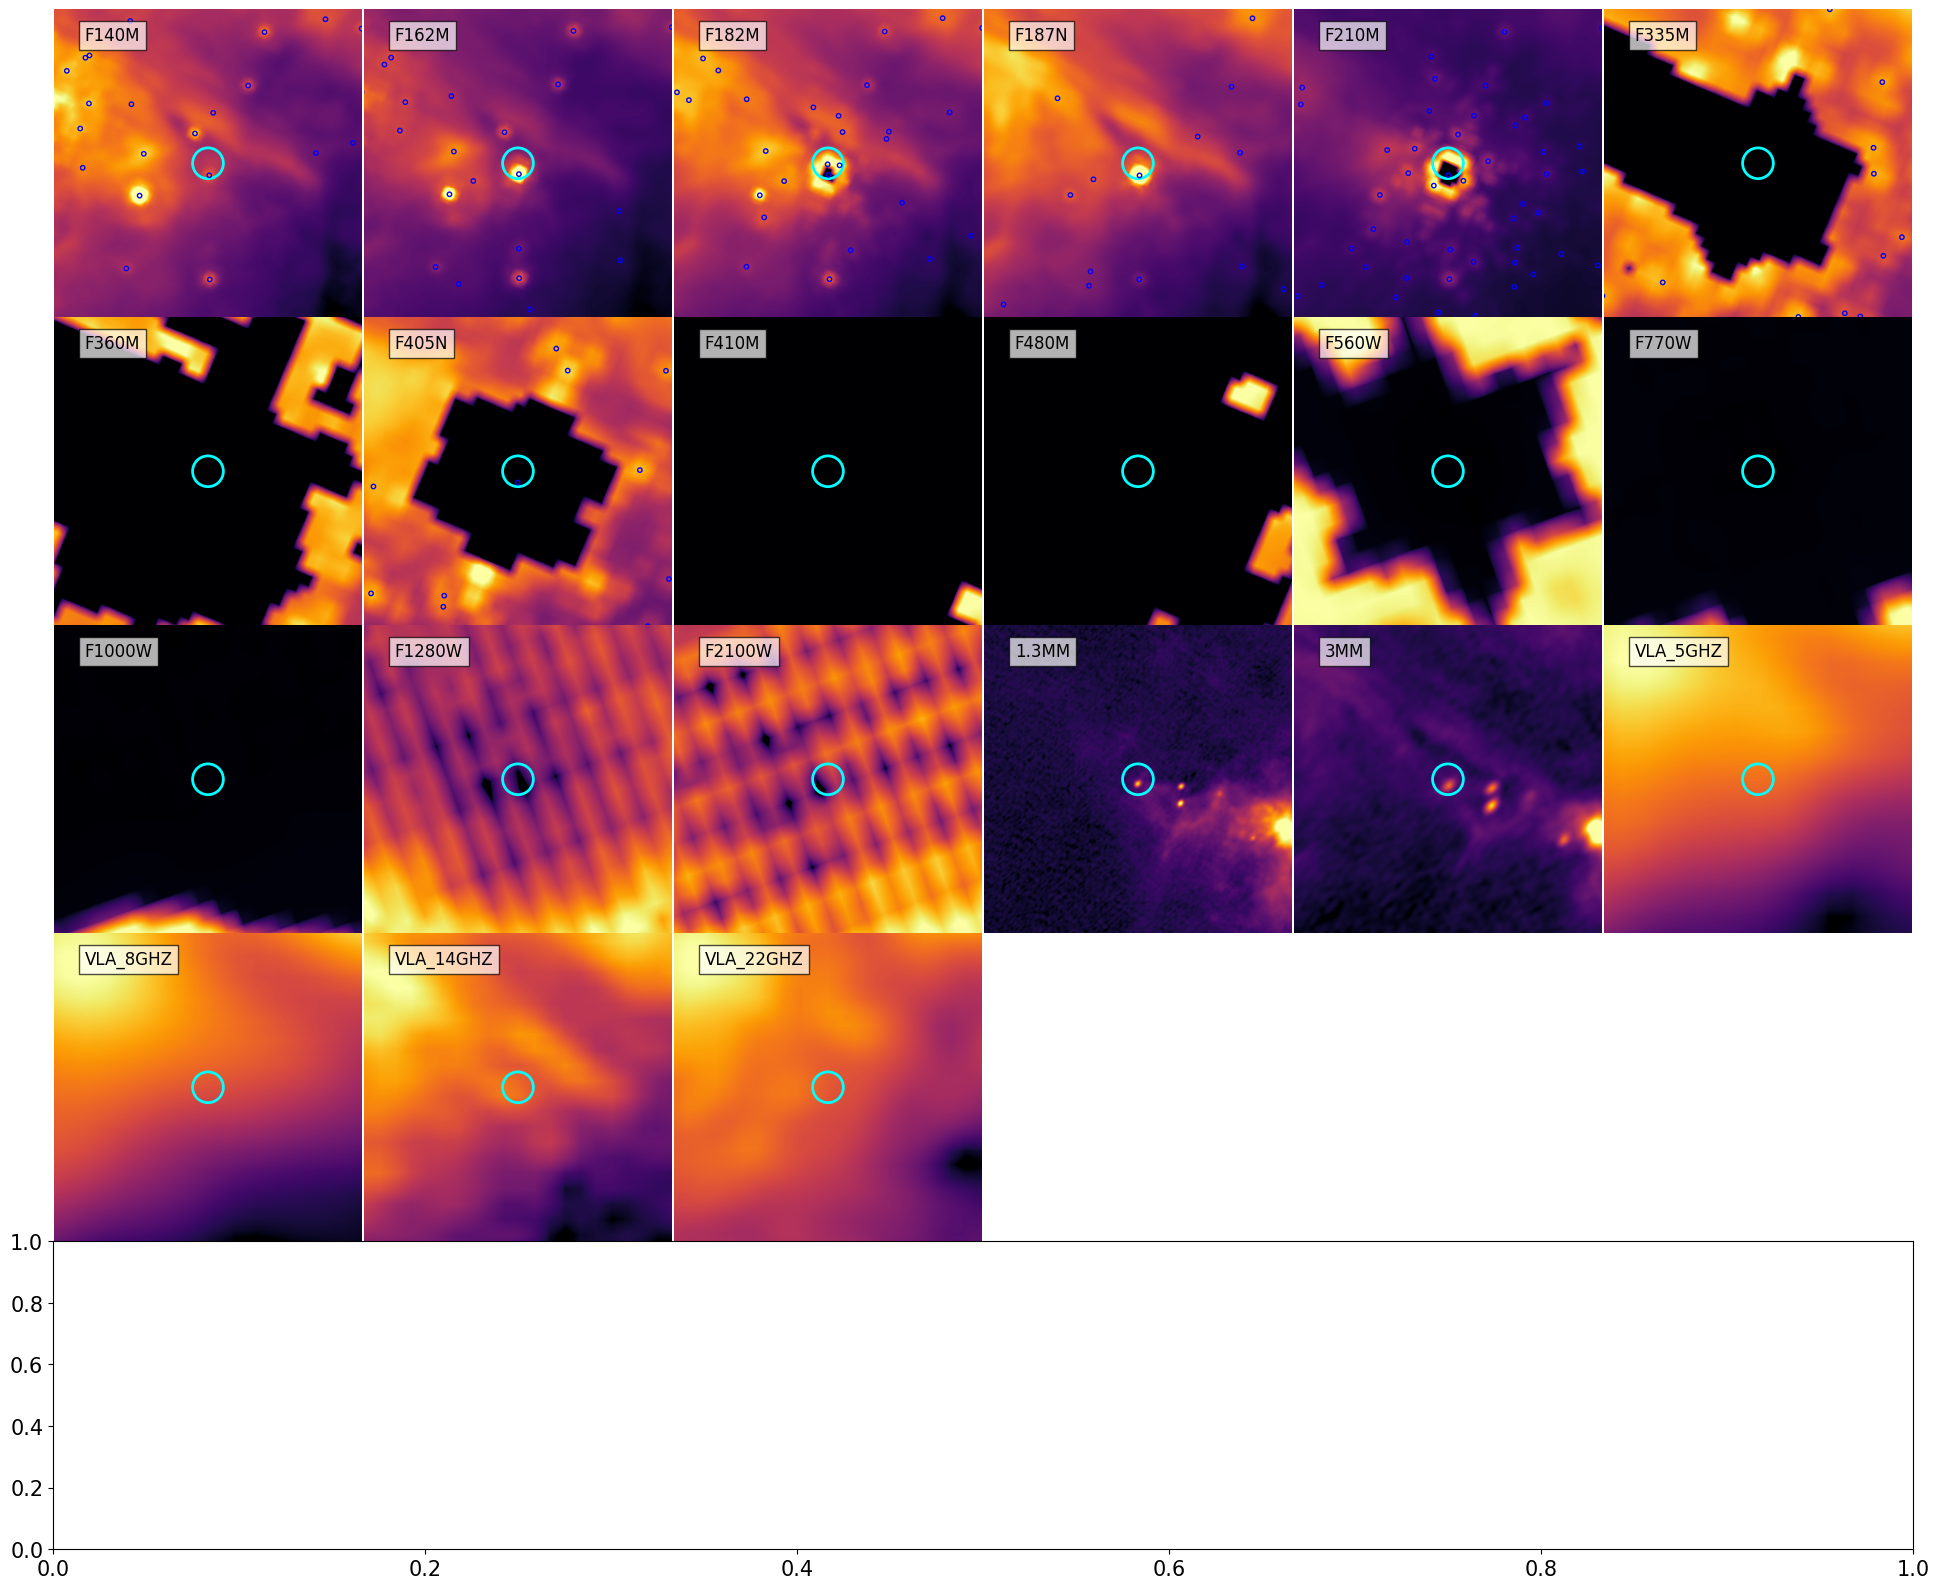

In [7]:
w51n_alma_tab = Table.read(w51n_alma_catalog)
print(w51n_alma_tab.colnames)
w51n_alma_ra = Table.read(w51n_alma_catalog)['ra']
w51n_alma_dec = Table.read(w51n_alma_catalog)['dec']
mag_f140m_w51n_arr = []
mag_f210m_w51n_arr = []
mag_f360m_w51n_arr = []
mag_f480m_w51n_arr = []
for ii,id in enumerate(w51n_matched_idx):
    if True:
        if ii==0: 
            show=True
        else:
            show =False
        skycoord_alma = SkyCoord(ra=w51n_alma_ra[id]*u.deg, dec=w51n_alma_dec[id]*u.deg)
        skycoord_jwst = SkyCoord(ra=jwst_tab['skycoord_ref'].ra, dec=jwst_tab['skycoord_ref'].dec)
        idx, d2d, d3d = skycoord_alma.match_to_catalog_sky(skycoord_jwst)
        print(f"W51n ALMA source index: {id}, matched JWST catalog index: {idx}, separation: {d2d.arcsec} arcsec")
        row_jwst = jwst_tab[idx]
        row_alma = Table.read(w51n_alma_catalog)[id]
        vla_ra = vla_cat_updated['GRAdeg']
        vla_dec = vla_cat_updated['GDEdeg']
        finite_idx = np.isfinite(vla_ra) & np.isfinite(vla_dec)
        vla_cat_updated = vla_cat_updated[finite_idx]
        vla_ra= vla_cat_updated['GRAdeg']
        vla_dec = vla_cat_updated['GDEdeg']
        
        skycoord_vla = SkyCoord(ra=vla_ra, dec=vla_dec)
        # get the indices of the VLA sources that are within 0.1 arcsec from the ALMA source
        separations = skycoord_vla.separation(skycoord_alma)
        vla_match_idx = np.where(separations < 0.1*u.arcsec)[0]
        if len(vla_match_idx) > 0:
            row_vla = vla_cat_updated[vla_match_idx]
            print(row_vla)
            print(f"Found {len(row_vla)} VLA sources within 0.1 arcsec of ALMA source {id}")
        else:
            row_vla = None
            print(f"No VLA sources found within 0.1 arcsec of ALMA source {id}")
        mags = plot_SED(image_filenames, row_jwst, row_alma, row_vla, f"W51IRS2_{id}", show=show, alma_region='w51n')
        if mags is not None:
            mag_f140m_w51n_arr.append(mags[0].value)
            mag_f210m_w51n_arr.append(mags[1].value)
            mag_f360m_w51n_arr.append(mags[2].value)
            mag_f480m_w51n_arr.append(mags[3].value)

In [ ]:
dd

In [ ]:

mag_f140m_w51e_arr = []
mag_f210m_w51e_arr = []
mag_f360m_w51e_arr = []
mag_f480m_w51e_arr = []
for ii,id in enumerate(w51e_matched_idx):
    if True:
        skycoord_alma = SkyCoord(ra=w51e_alma_ra[id]*u.deg, dec=w51e_alma_dec[id]*u.deg)
        skycoord_jwst = SkyCoord(ra=jwst_tab['skycoord_ref'].ra, dec=jwst_tab['skycoord_ref'].dec)
        idx, d2d, d3d = skycoord_alma.match_to_catalog_sky(skycoord_jwst)
        print(f"W51e ALMA source index: {id}, matched JWST catalog index: {idx}, separation: {d2d.arcsec} arcsec")
        row_jwst = jwst_tab[idx]
        row_alma = Table.read(w51e_alma_catalog)[id]
        vla_ra = vla_cat_updated['GRAdeg']
        vla_dec = vla_cat_updated['GDEdeg']
        finite_idx = np.isfinite(vla_ra) & np.isfinite(vla_dec)
        vla_cat_updated = vla_cat_updated[finite_idx]
        vla_ra= vla_cat_updated['GRAdeg']
        vla_dec = vla_cat_updated['GDEdeg']
        
        skycoord_vla = SkyCoord(ra=vla_ra, dec=vla_dec)
        # get the indices of the VLA sources that are within 0.1 arcsec from the ALMA source
        separations = skycoord_vla.separation(skycoord_alma)
        vla_match_idx = np.where(separations < 0.1*u.arcsec)[0]
        if len(vla_match_idx) > 0:
            row_vla = vla_cat_updated[vla_match_idx]
            print(f"Found {len(row_vla)} VLA sources within 0.1 arcsec of ALMA source {id}")
        else:
            row_vla = None
        mags = plot_SED(image_filenames, row_jwst, row_alma, row_vla, f"W51E_{id}", show=False)
        if mags is not None:
            mag_f140m_w51e_arr.append(mags[0].value)
            mag_f210m_w51e_arr.append(mags[1].value)
            mag_f360m_w51e_arr.append(mags[2].value)
            mag_f480m_w51e_arr.append(mags[3].value)

W51e ALMA source index: 3, matched JWST catalog index: 149208, separation: [0.03356093] arcsec
skycoords in h:m:s: 19h23m43.79121482s +14d30m19.78680886s
21 21
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f140m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f140m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f162m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f162m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: 

/scratch/local/28789662/ipykernel_2990470/357027548.py:357: UserWarning: Warning: converting a masked element to nan.
  fluxarr = np.array(fluxarr)


W51e ALMA source index: 7, matched JWST catalog index: 133964, separation: [0.03937118] arcsec
skycoords in h:m:s: 19h23m43.50583402s +14d30m21.79695539s
21 21
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f140m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f140m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f162m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f162m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: 

/scratch/local/28789662/ipykernel_2990470/357027548.py:357: UserWarning: Warning: converting a masked element to nan.
  fluxarr = np.array(fluxarr)


W51e ALMA source index: 36, matched JWST catalog index: 40598, separation: [0.01941872] arcsec
skycoords in h:m:s: 19h23m43.99340581s +14d30m33.14299118s
21 21
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f140m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f140m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f162m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f162m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: 

...

/scratch/local/28789662/ipykernel_2990470/357027548.py:357: UserWarning: Warning: converting a masked element to nan.
  fluxarr = np.array(fluxarr)


W51e ALMA source index: 95, matched JWST catalog index: 63026, separation: [0.04309606] arcsec
skycoords in h:m:s: 19h23m44.0640837s +14d30m32.62497077s
21 21
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f140m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f140m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f162m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f162m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: /

/scratch/local/28789662/ipykernel_2990470/357027548.py:357: UserWarning: Warning: converting a masked element to nan.
  fluxarr = np.array(fluxarr)


W51e ALMA source index: 106, matched JWST catalog index: 40491, separation: [0.03967291] arcsec
skycoords in h:m:s: 19h23m43.77872026s +14d30m45.8897021s
21 21
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f140m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f140m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f162m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f162m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: 

/scratch/local/28789662/ipykernel_2990470/357027548.py:357: UserWarning: Warning: converting a masked element to nan.
  fluxarr = np.array(fluxarr)


In [ ]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89

def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err



catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_refined.fits')
print(catalog.colnames)
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = RL85_MWGC()
ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=RL85_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'{label}', linestyle='-', linewidth=2)



imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
filters = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(filters.keys())

def get_line_excess(catalog, narrow, wide):
    # --- Convert catalog MJy/sr → Jy ---
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))

    data_narrow = (catalog['flux_fit_' + narrow] * u.MJy/u.sr *
                   ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (catalog['flux_fit_' + wide] * u.MJy/u.sr *
                 ww_wide.proj_plane_pixel_area()).to(u.Jy)

    # --- Load filter curves ---
    tab_n = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    tab_w = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    wave_n = tab_n['Wavelength'] * u.AA
    trans_n = tab_n['Transmission']

    wave_w = tab_w['Wavelength'] * u.AA
    trans_w = tab_w['Transmission']

    # --- Interpolate narrow onto wide grid ---
    trans_n_interp = np.interp(wave_w.value, wave_n.value, trans_n)

    # --- Fractional overlap (proper integral) ---
    num = np.trapezoid(
    (trans_w / trans_w.max()) * (trans_n_interp / trans_n.max()),
    wave_w.value
    )
    den = np.trapezoid(trans_w / trans_w.max(), wave_w.value)
    f = num / den

    if np.isclose(f, 1.0):
        return None, None

    # --- Continuum & line (still in Jy = F_nu) ---
    cont_nu = (data_wide - data_narrow * f) / (1 - f)
    line_nu = data_narrow - cont_nu

    width_narrow = np.trapezoid(trans_n / trans_n.max(), wave_n.value) * u.AA

    # --- Equivalent Width ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ew = (line_nu / cont_nu) * width_narrow

    return line_nu.value, ew.to_value(u.AA)

paa_excess,  paa_excess_ew = get_line_excess(catalog, 'f187n', 'f182m')
bra_excess,  bra_excess_ew = get_line_excess(catalog, 'f405n', 'f410m')

print('paa_excess', paa_excess)



['skycoord_ref', 'skycoord_ref_filtername', 'sep_f140m', 'id_f140m', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'mask_f140m', 'qfit_f140m', 'cfit_f140m', 'local_bkg_f140m', 'roundness1_f140m', 'roundness2_f140m', 'sharpness_f140m', 'from_sat_catalog_f140m', 'std_ra_f140m', 'std_dec_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'flux_err_prop_f140m', 'sep_f162m', 'id_f162m', 'skycoord_f162m', 'flux_fit_f162m', 'flux_err_f162m', 'mask_f162m', 'qfit_f162m', 'cfit_f162m', 'local_bkg_f162m', 'roundness1_f162m', 'roundness2_f162m', 'sharpness_f162m', 'from_sat_catalog_f162m', 'std_ra_f162m', 'std_dec_f162m', 'nmatch_f162m', 'nmatch_good_f162m', 'flux_err_prop_f162m', 'sep_f182m', 'id_f182m', 'skycoord_f182m', 'flux_fit_f182m', 'flux_err_f182m', 'mask_f182m', 'qfit_f182m', 'cfit_f182m', 'local_bkg_f182m', 'roundness1_f182m', 'roundness2_f182m', 'sharpness_f182m', 'from_sat_catalog_f182m', 'std_ra_f182m', 'std_dec_f182m', 'nmatch_f182m', 'nmatch_good_f182m', 'flux_err_prop_f182m', 's

Model: CT06_MWLoc
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.4 um 2.1 um 3.6 um 4.8 um
1.4 um 2.1 um 3.6 um 4.8 um
7.129363200000001 3.4739712 1.7993024000000004 1.454796
Model: RL85_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.4 um 2.1 um 3.6 um 4.8 um
1.4 um 2.1 um 3.6 um 4.8 um
7.0412946428571415 3.6726315789473687 1.6323076923076927 0.69
Model: CT06_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.4 um 2.1 um 3.6 um 4.8 um
1.4 um 2.1 um 3.6 um 4.8 um
7.129363200000001 3.4739712 1.7993024000000004 1.454796
Model: G21_MWAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.4 um 2.1 um 3.6 um 4.8 um
1.4 um 2.1 um 3.6 um 4.8 um
6.673350218462829 3.662529750810622 1.6526084768147404 1.0894231111576114
Model: RRP89_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.4 um 2.1 um 3.6 um 4.8 um
1.4 um 2.1 um 3.6 um 4.8 um
6.877352882900731 3.598397287717673 1.9293004729897925 0.9708737864077621
Model:

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(


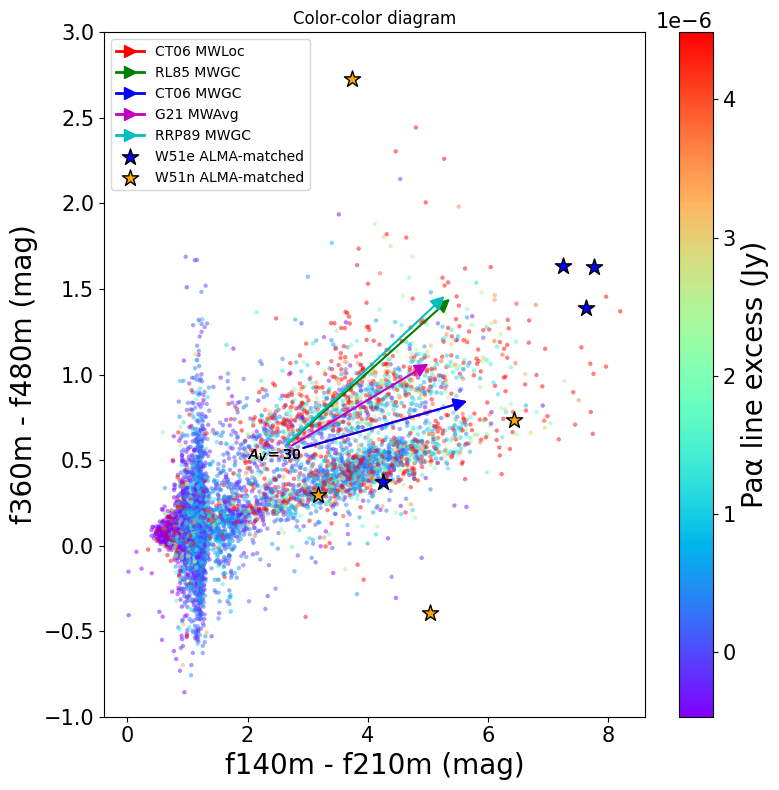

In [ ]:

from dust_extinction.averages import RL85_MWGC, CT06_MWLoc, CT06_MWGC, G21_MWAvg, RRP89_MWGC, G24_SMCAvg
def plot_extvec_ccd(ax, color1, color2, ext=RL85_MWGC(), extvec_scale=30, start=None,
                    color='y', head_width=0.5, color1_data=None, color2_data=None, label=None):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(color2[0])
    w4 = get_wave(color2[1])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    if w3 > w4:
        w3, w4 = w4, w3
        color2 = color2[::-1]
    print(w1,w2,w3,w4)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
        e_4 = ext(1/w4) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3,w4)
    print(e_1, e_2, e_3, e_4)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_color2 = np.nanmean(color2_data)
        std_color1 = np.nanstd(color1_data)
        std_color2 = np.nanstd(color2_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        if e_3 - e_4 < 0:
            std_color2 *= -1
    
        start2 = (mean_color1 + 2*std_color1, mean_color2 + 2*std_color2)
    else:
        start2 = start

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2[0] + (e_1 - e_2), start2[1] + (e_3 - e_4)),
                xytext=(start2[0], start2[1]),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'{label}', linestyle='-', linewidth=2)

# 140-210 vs 360-480 color coded by paa excess
color1 = filters['f140m'][0] - filters['f210m'][0]
color2 = filters['f360m'][0] - filters['f480m'][0]
color_for_points = paa_excess


fig = plt.figure(figsize=(8,8))
ax = fig.add_axes(111)
cmap = plt.get_cmap('rainbow')
norm = plt.Normalize(vmin=np.nanpercentile(color_for_points, 10), vmax=np.nanpercentile(color_for_points, 90))
ax.scatter(color1.value, color2.value, s=10, c=color_for_points, cmap=cmap, alpha=0.5, edgecolor='none', norm=norm)
ax.set_xlabel('f140m - f210m (mag)')
ax.set_ylabel('f360m - f480m (mag)')
ax.set_title('Color-color diagram')
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label('Paα line excess (Jy)')
ax.set_ylim(-1,3)

colorlist = ['r', 'g', 'b', 'm', 'c', 'y']
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), CT06_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'CT06 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_ccd(ax, color1=('f140m', 'f210m'), color2=('f360m', 'f480m'),
                     ext=ext_model, extvec_scale=30, color=c,
                     color1_data=color1, color2_data=color2, start=(2,0.5), label=labels)
ax.scatter(np.array(mag_f140m_w51e_arr) - np.array(mag_f210m_w51e_arr), np.array(mag_f360m_w51e_arr) - np.array(mag_f480m_w51e_arr), edgecolor='k', s=150, c='b', marker='*', label='W51e ALMA-matched')
ax.scatter(np.array(mag_f140m_w51n_arr) - np.array(mag_f210m_w51n_arr), np.array(mag_f360m_w51n_arr) - np.array(mag_f480m_w51n_arr), edgecolor='k', s=150, c='orange', marker='*', label='W51n ALMA-matched')

ax.legend()
plt.tight_layout()
plt.show()
